# Import libraries and functions

In [1]:
import numpy as np
import pandas as pd
import openpyxl
from datetime import datetime
import plotly.graph_objs as go
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import griddata

from Functions import (
    black_call_put_price, 
    heston_rmse_loss,
    heston_rmse_loss_smart,
    compute_heston_prices, 
    implied_volatility_row, 
    plot_mkt_vs_model_iv
)


# Read and transform data for easier handling 

In [2]:
# Ruta a tu archivo Excel
path = r'Data\Implied vols TTF - 2025 05 23.xlsx' 

table_cell_range = 'B6:K23'

# reference date
ref_date = datetime(2025, 5, 24, 0, 0, 0) # Year, month, day, hour, minute, second

# Read the different sheets
df_jul25 = pd.read_excel(path, sheet_name='Jul 25', usecols='B:K',skiprows=5,nrows=17)
ATM_fwd = pd.read_excel(path, sheet_name='Jul 25', usecols='H:H',skiprows=2,nrows=1); atm_forward_value = ATM_fwd.iloc[0, 0]
df_jul25['ATM Forward'] = atm_forward_value

df_dec25 = pd.read_excel(path, sheet_name='Dec 25', usecols='B:K',skiprows=5,nrows=17)
ATM_fwd = pd.read_excel(path, sheet_name='Dec 25', usecols='H:H',skiprows=2,nrows=1); atm_forward_value = ATM_fwd.iloc[0, 0]
df_dec25['ATM Forward'] = atm_forward_value

df_jun26 = pd.read_excel(path, sheet_name='Jun 26', usecols='B:K',skiprows=5,nrows=17)
ATM_fwd = pd.read_excel(path, sheet_name='Jun 26', usecols='H:H',skiprows=2,nrows=1); atm_forward_value = ATM_fwd.iloc[0, 0]
df_jun26['ATM Forward'] = atm_forward_value

df_dec26 = pd.read_excel(path, sheet_name='Dec 26', usecols='B:K',skiprows=5,nrows=17)
ATM_fwd = pd.read_excel(path, sheet_name='Dec 26', usecols='H:H',skiprows=2,nrows=1); atm_forward_value = ATM_fwd.iloc[0, 0]
df_dec26['ATM Forward'] = atm_forward_value

df = pd.concat([df_jul25,df_dec25,df_jun26,df_dec26])

df.drop(['BID','ASK','TRDTIM_1','HISTORIC CLOSE'], axis=1, inplace=True)
df.reset_index(inplace=True)

# Time to Maturity
df['TTM'] = df['EXPIRE DATE'] - ref_date
df['TTM'] = df['TTM'].dt.days/365



# Compute option prices using the Black model

In [3]:
# Discount rate
rate = 0.0352
#df['Discount Factor'] = np.exp(-df['TTM']*rate)

df[['call_price', 'put_price']] = df.apply(lambda row: black_call_put_price(
    F=row['ATM Forward'],
    K=row['STRIKE_PRC'],
    r = rate,
    sigma=row['LAST'] / 100,
    T=row['TTM'],
), axis=1, result_type='expand')

new_columns = {col: col.replace(' ', '_') for col in df.columns}

# Rename the columns
df = df.rename(columns=new_columns)

# Plot volatility smiles

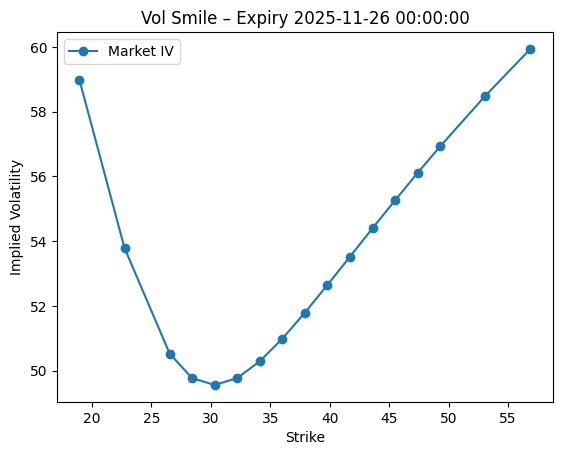

In [4]:
maturities = list(df['EXPIRE_DATE'].unique()); maturities

mat =  maturities[1]

df1 = df[df['EXPIRE_DATE'] == mat]


plt.figure()
plt.plot(df1['STRIKE_PRC'], df1['LAST'], 'o-', label='Market IV')
plt.title(f'Vol Smile – Expiry {mat}')
plt.xlabel('Strike')
plt.ylabel('Implied Volatility')
plt.legend()
plt.show()

# Calibrate and plot each maturity independently

In [5]:
calibrated_params = {}
data_by_maturity = {}
errors = {}

for maturity in list(df['EXPIRE_DATE'].unique()):
    
    str_maturity = str(pd.to_datetime(maturity).date())

    data = df[df['EXPIRE_DATE'] == maturity]
    data_by_maturity[str_maturity] = data
    #data = df[(df['EXPIRE_DATE'] == maturities[0]) | (df['EXPIRE_DATE'] == maturities[1])]

    # Initial guess and bounds
    initial_guess = [1.0, 0.04, 0.5, -0.5, 0.04]  # [kappa, theta, sigma, rho, v0]
    bounds = [
        (1e-3, 10),     # kappa
        (1e-4, 1),      # theta
        (1e-3, 5),      # sigma
        (-0.999, 0.999),# rho
        (1e-4, 1)       # v0
    ]
    r=0.0352
    result = minimize(heston_rmse_loss, initial_guess, args=(data, r), bounds=bounds, method='L-BFGS-B')
    result_putcall =  minimize(heston_rmse_loss_smart, initial_guess, args=(data, r), bounds=bounds, method='L-BFGS-B')

    if result.success:
        calibrated_params[str_maturity] = result.x
        errors[str_maturity] = result.fun
        print(f"Calibrated parameters {str_maturity}: \
            \n kappa: {calibrated_params[str_maturity][0]} \
            \n theta: {calibrated_params[str_maturity][1]} \
            \n sigma: {calibrated_params[str_maturity][2]} \
            \n rho: {calibrated_params[str_maturity][3]} \
            \n V0: {calibrated_params[str_maturity][4]} \
            \n Error: {errors[str_maturity]}\n {'-'*80} ")
    else:
        print("Optimization failed:", result.message)


Calibrated parameters 2025-06-26:             
 kappa: 6.1136552227460825             
 theta: 0.9881071787634396             
 sigma: 4.551741505453466             
 rho: 0.2769990747375089             
 V0: 0.03609491073070047             
 Error: 0.005480934298502268
 -------------------------------------------------------------------------------- 
Calibrated parameters 2025-11-26:             
 kappa: 0.5887022051492695             
 theta: 0.024960625438640246             
 sigma: 1.101230311958523             
 rho: 0.29840120445084917             
 V0: 0.34152741744332793             
 Error: 0.027809033717734792
 -------------------------------------------------------------------------------- 
Calibrated parameters 2026-05-27:             
 kappa: 0.11009737428191903             
 theta: 0.34230869106439826             
 sigma: 0.9107659697929762             
 rho: 0.14232755918645282             
 V0: 0.2482344000663005             
 Error: 0.007755092640645654
 --------------

C:\Users\ramon\AppData\Local\Temp\ipykernel_15872\61987530.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'Heston_call_price'] = data.apply(compute_heston_prices, axis=1, heston_params = calibrated_params[maturity], r=0.0352, option_type='call')
C:\Users\ramon\AppData\Local\Temp\ipykernel_15872\61987530.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Heston_call_IV'] = data.apply(implied_volatility_row, axis=1, r=r, option_type='call')


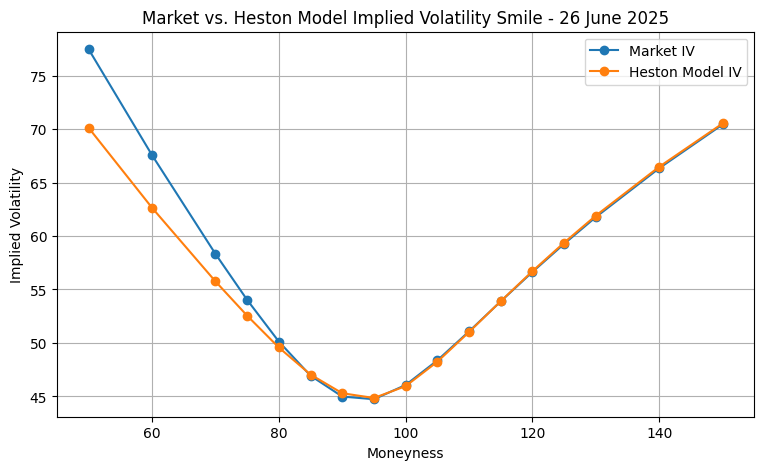

C:\Users\ramon\AppData\Local\Temp\ipykernel_15872\61987530.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'Heston_call_price'] = data.apply(compute_heston_prices, axis=1, heston_params = calibrated_params[maturity], r=0.0352, option_type='call')
C:\Users\ramon\AppData\Local\Temp\ipykernel_15872\61987530.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Heston_call_IV'] = data.apply(implied_volatility_row, axis=1, r=r, option_type='call')


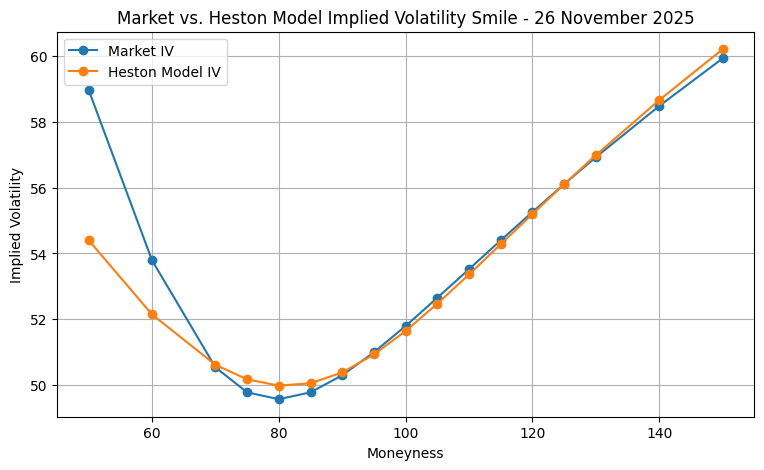

C:\Users\ramon\AppData\Local\Temp\ipykernel_15872\61987530.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'Heston_call_price'] = data.apply(compute_heston_prices, axis=1, heston_params = calibrated_params[maturity], r=0.0352, option_type='call')
C:\Users\ramon\AppData\Local\Temp\ipykernel_15872\61987530.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Heston_call_IV'] = data.apply(implied_volatility_row, axis=1, r=r, option_type='call')


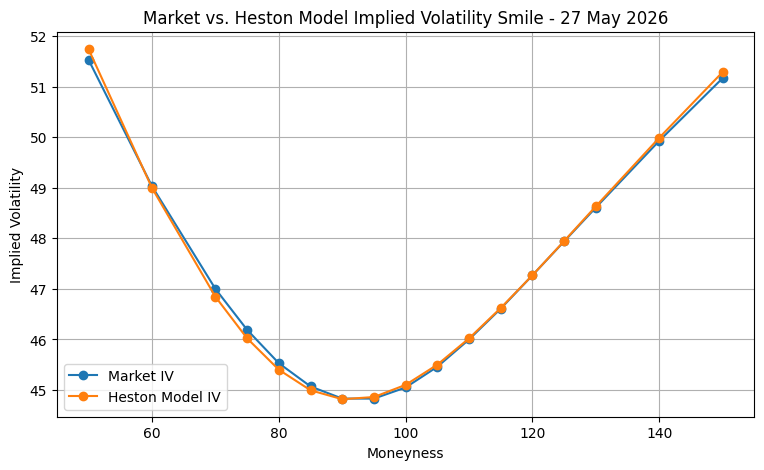

C:\Users\ramon\AppData\Local\Temp\ipykernel_15872\61987530.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'Heston_call_price'] = data.apply(compute_heston_prices, axis=1, heston_params = calibrated_params[maturity], r=0.0352, option_type='call')
C:\Users\ramon\AppData\Local\Temp\ipykernel_15872\61987530.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Heston_call_IV'] = data.apply(implied_volatility_row, axis=1, r=r, option_type='call')


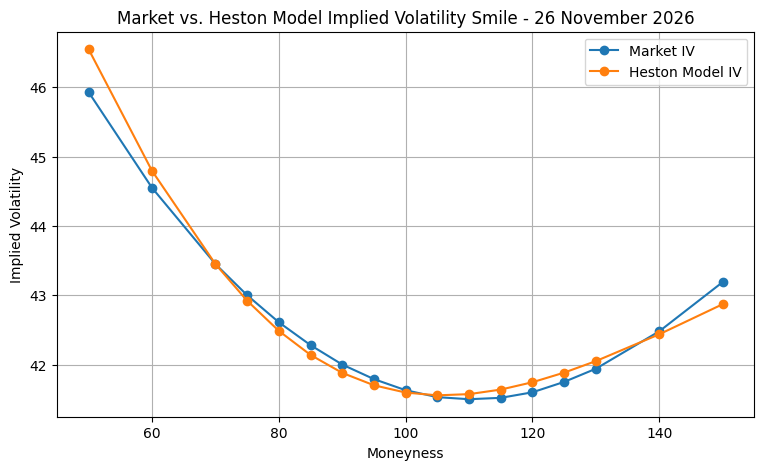

In [6]:
for maturity,data in data_by_maturity.items():
    
    data.loc[:,'Heston_call_price'] = data.apply(compute_heston_prices, axis=1, heston_params = calibrated_params[maturity], r=0.0352, option_type='call')   
    data['Heston_call_IV'] = data.apply(implied_volatility_row, axis=1, r=r, option_type='call')

    plot_mkt_vs_model_iv(data, maturity)


# All maturities calibration and vol surface comparison

In [7]:
# Ruta a tu archivo Excel
path = r'Data\Implied vols TTF - 2025 05 23.xlsx' 

table_cell_range = 'B6:K23'

# reference date
ref_date = datetime(2025, 5, 24, 0, 0, 0) # Year, month, day, hour, minute, second

# Read the different sheets
df_jul25 = pd.read_excel(path, sheet_name='Jul 25', usecols='B:K',skiprows=5,nrows=17)
ATM_fwd = pd.read_excel(path, sheet_name='Jul 25', usecols='H:H',skiprows=2,nrows=1); atm_forward_value = ATM_fwd.iloc[0, 0]
df_jul25['ATM Forward'] = atm_forward_value

df_dec25 = pd.read_excel(path, sheet_name='Dec 25', usecols='B:K',skiprows=5,nrows=17)
ATM_fwd = pd.read_excel(path, sheet_name='Dec 25', usecols='H:H',skiprows=2,nrows=1); atm_forward_value = ATM_fwd.iloc[0, 0]
df_dec25['ATM Forward'] = atm_forward_value

df_jun26 = pd.read_excel(path, sheet_name='Jun 26', usecols='B:K',skiprows=5,nrows=17)
ATM_fwd = pd.read_excel(path, sheet_name='Jun 26', usecols='H:H',skiprows=2,nrows=1); atm_forward_value = ATM_fwd.iloc[0, 0]
df_jun26['ATM Forward'] = atm_forward_value

df_dec26 = pd.read_excel(path, sheet_name='Dec 26', usecols='B:K',skiprows=5,nrows=17)
ATM_fwd = pd.read_excel(path, sheet_name='Dec 26', usecols='H:H',skiprows=2,nrows=1); atm_forward_value = ATM_fwd.iloc[0, 0]
df_dec26['ATM Forward'] = atm_forward_value

df = pd.concat([df_jul25,df_dec25,df_jun26,df_dec26])

df.drop(['BID','ASK','TRDTIM_1','HISTORIC CLOSE'], axis=1, inplace=True)
df.reset_index(inplace=True)

# Time to Maturity
df['TTM'] = df['EXPIRE DATE'] - ref_date
df['TTM'] = df['TTM'].dt.days/365

# Discount rate
rate = 0.0352
#df['Discount Factor'] = np.exp(-df['TTM']*rate)

df[['call_price', 'put_price']] = df.apply(lambda row: black_call_put_price(
    F=row['ATM Forward'],
    K=row['STRIKE_PRC'],
    r = rate,
    sigma=row['LAST'] / 100,
    T=row['TTM'],
), axis=1, result_type='expand')

new_columns = {col: col.replace(' ', '_') for col in df.columns}

# Rename the columns
df = df.rename(columns=new_columns)


In [8]:
from mpl_toolkits.mplot3d import Axes3D

df_all = df

# Calibrate globally

initial_guess = [1.0, 0.04, 0.5, -0.5, 0.04]  # [kappa, theta, sigma, rho, v0]
bounds = [
    (1e-3, 10),     # kappa
    (1e-4, 1),      # theta
    (1e-3, 5),      # sigma
    (-0.999, 0.999),# rho
    (1e-4, 1)       # v0
]
r=0.0352
res_global = minimize(heston_rmse_loss, initial_guess, args=(df_all, r),
                    bounds=bounds, method='L-BFGS-B')
params_global = res_global.x if res_global.success else None
error_global = res_global.fun if res_global.success else None

print(f"Calibrated parameters: \
            \n kappa: {params_global[0]} \
            \n theta: {params_global[1]} \
            \n sigma: {params_global[2]} \
            \n rho: {params_global[3]} \
            \n V0: {params_global[4]} \
            \n Error: {error_global}\n {'-'*80} ")




Calibrated parameters:             
 kappa: 0.6745708852398997             
 theta: 0.0001             
 sigma: 0.8922277645942117             
 rho: 0.10226072435802298             
 V0: 0.34029629303683745             
 Error: 0.1741386559048056
 -------------------------------------------------------------------------------- 


# Plot vol surfaces

In [9]:
df_all.loc[:,'Heston_call_price'] = df_all.apply(compute_heston_prices, axis=1, heston_params = params_global, r=0.0352, option_type='call')   
df_all['Heston_call_IV'] = df_all.apply(implied_volatility_row, axis=1, r=r, option_type='call')

strike_grid, ttm_grid = df_all['STRIKE_PRC'], df_all['TTM']
iv_market_grid, iv_model_grid = df_all['LAST'], df_all['Heston_call_IV']*100

### 1.- Market implied vol surface

In [12]:
#Make grids for Plotly surface
xi = np.linspace(min(strike_grid), max(strike_grid), 50)
yi = np.linspace(min(ttm_grid), max(ttm_grid), 50)
xi, yi = np.meshgrid(xi, yi)

# Interpolate Z values for smooth surface
zi_market = griddata((strike_grid, ttm_grid), iv_market_grid, (xi, yi), method='cubic')
zi_model  = griddata((strike_grid, ttm_grid), iv_model_grid,  (xi, yi), method='cubic')


# Create Market IV Surface
surface_market = go.Surface(
    x=xi, y=yi, z=zi_market,
    colorscale='Viridis',
    name='Market IV',
    showscale=True,
    colorbar=dict(
        # Position the colorbar closer to the plot
        x=0.75, 
        xpad=0, 
        y=0.5, 
        len=0.8, 
    )
)

# Layout
layout_market = go.Layout(
    title=dict(
        text='Market Implied Volatility Surface',
        x=0.5, 
        xanchor='center', 
        y=0.95, 
        yanchor='top', 
    ),
    width=900,
    height=500,
    scene=dict(
        xaxis_title='Strike',
        yaxis_title='Time to Maturity',
        zaxis_title='Implied Volatility',
        camera=dict(eye=dict(x=1.3, y=1.3, z=1.1))
    )
)

fig_market = go.Figure(data=[surface_market], layout=layout_market)
fig_market.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 2. Heston vs implied vol surfaces

### We plot the market implied vol surfaces vs the surface given by the Heston model that was calibrated for all periods at the same time

In [ ]:

strike_grid, ttm_grid = df_all['STRIKE_PRC'], df_all['TTM']
iv_market_grid, iv_model_grid = df_all['LAST'], df_all['Heston_call_IV']*100

# Create interpolation grid
xi = np.linspace(min(strike_grid), max(strike_grid), 50)
yi = np.linspace(min(ttm_grid), max(ttm_grid), 50)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the Z values
zi_market = griddata((strike_grid, ttm_grid), iv_market_grid, (xi, yi), method='cubic')
zi_model  = griddata((strike_grid, ttm_grid), iv_model_grid,  (xi, yi), method='cubic')

# Create Market IV surface
surface_market = go.Surface(
    x=xi, y=yi, z=zi_market,
    colorscale='Viridis',
    opacity=0.8,
    name='Market IV',
    colorbar=dict(title='Market IV', x=0.9), 
    showscale=True
)

# Create Model IV surface
surface_model = go.Surface(
    x=xi, y=yi, z=zi_model,
    colorscale='Reds',
    opacity=0.6,
    name='Model IV',
    colorbar=dict(title='Model IV', x=-0.),  # Left side
    showscale=True
)

# Layout
layout = go.Layout(
    width=900,              
    height=600,             
    title=dict(
        text='Heston model vs Market Implied Volatility Surface',
        x=0.5, 
        xanchor='center',
        y=0.95, 
        yanchor='top', 
    ),
    scene=dict(
        xaxis_title='Strike',
        yaxis_title='Time to Maturity',
        zaxis_title='Implied Volatility',
        camera=dict(eye=dict(x=1.2, y=1.8, z=1.3))
    ),
    margin=dict(l=40, r=40, t=40, b=50)  # tight margins
)

# Combine into one figure
fig = go.Figure(data=[surface_market, surface_model], layout=layout)

# Show the figure
fig.show()



### Now we take the 4 different models that were calibrated separately for each individual maturity and, using interpolation, we plot the volatility surface. Obviously the fit is much better than the single model.

In [ ]:
df_concat= pd.concat(list(data_by_maturity.values()))

strike_grid, ttm_grid = df_concat['STRIKE_PRC'], df_concat['TTM']
iv_market_grid, iv_model_grid = df_concat['LAST'], df_concat['Heston_call_IV']*100

import plotly.graph_objs as go
import numpy as np
from scipy.interpolate import griddata

# Assuming you already have:
# strike_grid, ttm_grid, iv_market_grid, iv_model_grid (all 1D arrays)

# Create interpolation grid
xi = np.linspace(min(strike_grid), max(strike_grid), 50)
yi = np.linspace(min(ttm_grid), max(ttm_grid), 50)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the Z values
zi_market = griddata((strike_grid, ttm_grid), iv_market_grid, (xi, yi), method='cubic')
zi_model  = griddata((strike_grid, ttm_grid), iv_model_grid,  (xi, yi), method='cubic')

# Create Market IV surface
surface_market = go.Surface(
    x=xi, y=yi, z=zi_market,
    colorscale='Viridis',
    opacity=0.8,
    name='Market IV',
    colorbar=dict(title='Market IV', x=1.02),  # Right side
    showscale=True
)

# Create Model IV surface
surface_model = go.Surface(
    x=xi, y=yi, z=zi_model,
    colorscale='Reds',
    opacity=0.6,
    name='Model IV',
    colorbar=dict(title='Model IV', x=-0.15), 
    showscale=True
)

# Layout: make it big and nice
layout = go.Layout(
    width=900,              
    height=600,              
    scene=dict(
        xaxis_title='Strike',
        yaxis_title='Time to Maturity',
        zaxis_title='Implied Volatility',
        camera=dict(eye=dict(x=1.4, y=1.4, z=1.1))
    ),
    margin=dict(l=50, r=50, t=80, b=50) 
)

# Combine into one figure
fig = go.Figure(data=[surface_market, surface_model], layout=layout)

# Show the figure
fig.show()


